# Robustness & XAI (Univariate Variante) unter CMAPSS‑ähnlichen Störungen (CNN + RandomForest, Binary Classification)

Dieses Notebook ist für **dein eigenes Tabular-Setting** (Features wie `mittelwert_temp`, …; Label `fehler`), aber die **Störungen/Szenarien** sind **analog zu CMAPSS** aufgebaut:

## Szenarien (CMAPSS‑Style)
1. **baseline**: keine Störung (Train/Eval clean)
2. **covariance_shift**: Feature‑Skalierung auf Subset (nur **Eval** auf Shift; Modell bleibt clean)
3. **environmental_shift**: Feature‑Bias auf Subset (nur **Eval** auf Shift; Modell bleibt clean)
4. **model_drift**: zusätzliche Trainingsphase auf drifted Daten (CNN: weitertrainieren; RF: neu trainieren)
5. **catastrophic_forgetting**: Domain A train → Fine‑Tune/Train auf Domain B → Eval auf A und B
6. **underfitting / overfitting**: absichtlich zu simpel / zu komplex bzw. zu wenig Daten

## XAI pro Szenario & Modell
### CNN (Keras)
- Gradients (Batch‑Aggregat) via `tf.GradientTape` (robust, ohne TF‑Explain Abhängigkeit)
- optional: `tf-explain` Integrated Gradients / Vanilla / SmoothGrad (wenn installiert)
- PDP (global, p(y=1))
- LIME (lokal)
- DiCE (counterfactuals, desired_class='opposite') via sklearn‑Wrapper
- Surrogate Tree Rules

### RandomForest (sklearn Pipeline)
- PDP (global)
- LIME (lokal)
- DiCE (CFs) (mit robusten Checks)
- Surrogate Tree Rules

> **Wichtig:** Du musst unten nur `df_base`, `feature_cols`, `label_col` setzen und ggf. `prepare_df(...)` an deine Daten anpassen.


In [1]:
# ============================================================
# 0) Imports (einmal, ohne Redundanz)
# ============================================================
import os
import glob
from typing import Optional, Sequence, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# TensorFlow / Keras (nur tf.keras)
import tensorflow as tf
from tensorflow.keras import layers, optimizers, metrics, callbacks
from tensorflow.keras.models import Sequential

# Optional XAI libs
HAS_TF_EXPLAIN = True
try:
    from tf_explain.core.integrated_gradients import IntegratedGradients as TFExplainIG
    from tf_explain.core.vanilla_gradients import VanillaGradients
    from tf_explain.core.smoothgrad import SmoothGrad
except Exception as e:
    HAS_TF_EXPLAIN = False
    print("tf-explain nicht verfügbar:", repr(e))

HAS_LIME = True
try:
    from lime import lime_tabular
except Exception as e:
    HAS_LIME = False
    print("lime nicht verfügbar:", repr(e))

HAS_DICE = True
try:
    import dice_ml
    from dice_ml import Dice
except Exception as e:
    HAS_DICE = False
    print("dice-ml nicht verfügbar:", repr(e))


In [2]:
# ============================================================
# 1) Config
# ============================================================
CONFIG = {
    "seed": 42,
    "univariate_feature": "mittelwert_temp",
    "id_col": "point_id",
    "local_point_ids": [398, 1996, 728],

    # Splits
    "train_frac": 0.7,
    "val_frac_within_train": 0.2,

    # CMAPSS-Style Störungen
    "cov_shift_scale": 1.3,
    "cov_shift_frac_features": 0.25,
    "env_shift_bias": 0.5,
    "env_shift_frac_features": 0.30,

    # Model drift
    "drift_extra_epochs": 20,   # CNN: weitertrainieren
    "rf_retrain_on_drift": True,

    # Catastrophic forgetting (Domain B = A + (cov+env shift))
    "forget_ft_epochs": 30,     # CNN fine-tune auf B
    "forget_rf_retrain": True,

    # Under/Overfitting
    "under_single_feature": None,   # z.B. "mittelwert_temp"
    "over_small_train_size": 500,

    # XAI
    "pdp_grid_resolution": 20,
    "pdp_sample_size": 500,
    "lime_num_features": 1,
    "lime_num_samples": 5000,
    "dice_total_cfs": 3,
    "dice_max_candidates": 30,
    "rules_tree_max_depth": 3,
    "rules_tree_min_samples_leaf": 50,
}

def ensure_point_id(df: pd.DataFrame, id_col: str = "point_id") -> pd.DataFrame:
    """Adds a stable integer id column if missing. Keeps row order."""
    df = df.copy()
    if id_col not in df.columns:
        df[id_col] = np.arange(len(df), dtype=int)
    return df


def set_seeds(seed: int = 42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(CONFIG["seed"])


In [3]:
# <-- Dein Ordner (laut Ausgabe)
pfad = r"C:\User\OneDrive - fir.rwth-aachen.de\Diss\99_Schreibversionen\Model 4\Daten Fallstudien\Cm4B2C\pressure"

dateien = glob.glob(os.path.join(pfad, "*.txt"))
assert len(dateien) > 0, "Keine Dateien gefunden – Pfad/Endung prüfen."

alle = []
for datei in dateien:
    # 1) Roh einlesen, am ' - ' trennen
    df = pd.read_csv(
        datei,
        sep=r"\s-\s",            # Trennt exakt am " - "
        engine="python",
        header=None,
        names=["zeit", "druck_raw"],
        dtype=str,
        on_bad_lines="skip"
    )

    # 2) Druck als Float aus "... PSI" extrahieren
    df["druck"] = (
        df["druck_raw"]
        .str.extract(r"([0-9]+(?:\.[0-9]+)?)")   # 362.69 aus "362.69 PSI"
        .astype(float)
    )

    # 3) Zeit parsen (deutsches Datum wie 10.7.2025, 12:29:01)
    df["zeit"] = pd.to_datetime(df["zeit"], format="%d.%m.%Y, %H:%M:%S", errors="coerce")

    # 4) Aufräumen & Quelle anhängen
    df = df.dropna(subset=["zeit", "druck"]).copy()
    df["quelle"] = os.path.basename(datei)
    alle.append(df[["zeit", "druck", "quelle"]])

# Zusammenführen
df_press = pd.concat(alle, ignore_index=True)

# Druckfehler markieren und zählen
df_press["druckfehler"] = df_press["druck"] < 340

df_press
# Optional: speichern
# df_press.to_csv(os.path.join(pfad, "pressure_parsed.csv"), index=False)

#Ordner mit Temperatur-Logs (.txt)
pfad_temp = r"C:\User\OneDrive - fir.rwth-aachen.de\Diss\99_Schreibversionen\Model 4\Daten Fallstudien\Cm4B2C\temperature"
dateien_temp = glob.glob(os.path.join(pfad_temp, "*.txt"))
assert len(dateien_temp) > 0, "Keine Temperaturdateien gefunden – Pfad/Endung prüfen."

alle_t = []
for datei in dateien_temp:
    # Split exakt am " - "
    df = pd.read_csv(
        datei,
        sep=r"\s-\s",
        engine="python",
        header=None,
        names=["zeit", "temp_raw"],
        dtype=str,
        on_bad_lines="skip",
    )

    # Zahl extrahieren (Komma oder Punkt) und in float wandeln
    val = df["temp_raw"].str.extract(r"([-+]?\d+(?:[.,]\d+)?)", expand=False)
    df["temp"] = val.str.replace(",", ".", regex=False).astype(float)

    # Zeit parsen (deutsches Datum wie 10.7.2025, 12:29:01)
    df["zeit"] = pd.to_datetime(df["zeit"], format="%d.%m.%Y, %H:%M:%S", errors="coerce")

    df = df.dropna(subset=["zeit", "temp"]).copy()
    df["quelle"] = os.path.basename(datei)
    alle_t.append(df[["zeit", "temp", "quelle"]])

df_temp = pd.concat(alle_t, ignore_index=True)
df_temp["tempfehler"] = df_temp["temp"] < 24.15


df = df_press.copy()     # oder: df = df_temp.copy()
wert_col = "druck"       # oder "temp"

# --- 1️⃣ Zeitstempel auf volle Minute runden ---
df["minute"] = df["zeit"].dt.floor("T")

# --- 2️⃣ Gruppieren nach Minute ---
gruppen = df.groupby("minute")[wert_col]

# --- 3️⃣ Kennzahlen berechnen ---
agg_df_press = gruppen.agg([
    "count",           # Anzahl Messungen pro Minute
    "mean",            # Mittelwert
    "median",          # Median
    "std",             # Standardabweichung
    "min", "max",      # Minimum / Maximum
    "skew"             # Schiefe (Skewness)
]).rename(columns={
    "count": "anzahl",
    "mean": "mittelwert",
    "median": "median",
    "std": "stdabw",
    "min": "minimum",
    "max": "maximum",
    "skew": "schiefe"
})

# --- 4️⃣ Quartile separat berechnen und anhängen ---
quartiles = gruppen.quantile([0.25, 0.75]).unstack()
agg_df_press["Q1"] = quartiles[0.25]
agg_df_press["Q3"] = quartiles[0.75]
agg_df_press["IQR"] = agg_df_press["Q3"] - agg_df_press["Q1"]

# --- 5️⃣ Optional: Druckfehler- oder Temperaturfehlerquote pro Minute ---
if "druckfehler" in df.columns:
    fehler = df.groupby("minute")["druckfehler"].mean()
    agg_df_press["fehlerquote"] = fehler * 100
elif "tempfehler" in df.columns:
    fehler = df.groupby("minute")["tempfehler"].mean()
    agg_df_press["fehlerquote"] = fehler * 100

# --- 6️⃣ Ergebnis ---
agg_df_press = agg_df_press.reset_index()
print(agg_df_press.head(10))

df = df_temp.copy()     # oder: df = df_temp.copy()
wert_col = "temp"       # oder "temp"

# --- 1️⃣ Zeitstempel auf volle Minute runden ---
df["minute"] = df["zeit"].dt.floor("T")

# --- 2️⃣ Gruppieren nach Minute ---
gruppen = df.groupby("minute")[wert_col]

# --- 3️⃣ Kennzahlen berechnen ---
agg_df_temp = gruppen.agg([
    "count",           # Anzahl Messungen pro Minute
    "mean",            # Mittelwert
    "median",          # Median
    "std",             # Standardabweichung
    "min", "max",      # Minimum / Maximum
    "skew"             # Schiefe (Skewness)
]).rename(columns={
    "count": "anzahl",
    "mean": "mittelwert",
    "median": "median",
    "std": "stdabw",
    "min": "minimum",
    "max": "maximum",
    "skew": "schiefe"
})

# --- 4️⃣ Quartile separat berechnen und anhängen ---
quartiles = gruppen.quantile([0.25, 0.75]).unstack()
agg_df_temp["Q1"] = quartiles[0.25]
agg_df_temp["Q3"] = quartiles[0.75]
agg_df_temp["IQR"] = agg_df_temp["Q3"] - agg_df_temp["Q1"]

# --- 5️⃣ Optional: Druckfehler- oder Temperaturfehlerquote pro Minute ---
if "tempfehler" in df.columns:
    fehler = df.groupby("minute")["tempfehler"].mean()
    agg_df_temp["fehlerquote"] = fehler * 100
elif "tempfehler" in df.columns:
    fehler = df.groupby("minute")["tempfehler"].mean()
    agg_df_temp["fehlerquote"] = fehler * 100

# --- 6️⃣ Ergebnis ---
agg_df_temp = agg_df_temp.reset_index()
print(agg_df_temp.head(10))

agg_df_press["druckfehler"] = (
    (agg_df_press["median"] < 340) |
    (agg_df_press["maximum"] > 400) |
    (agg_df_press["Q3"] > 375)
)

agg_df_temp["tempfehler"] = (
    (agg_df_temp["mittelwert"] < 23.7) |
    (agg_df_temp["stdabw"] > .025) |
    (agg_df_temp["Q1"] < 23.5)
)

merged = agg_df_temp.merge(
    agg_df_press,
    left_index=True,
    right_index=True,
    suffixes=("_temp", "_press")
)
merged["fehler"] = merged["tempfehler"] | merged["druckfehler"]
merged = merged.dropna()
merged

C:\Temp\ipykernel_8392\683231763.py:82: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df["minute"] = df["zeit"].dt.floor("T")


               minute  anzahl  mittelwert  median      stdabw  minimum  \
0 2025-07-10 12:29:00     117  278.481026   174.0  138.005851    174.0   
1 2025-07-10 12:30:00     120  285.851083   174.0  141.020684    174.0   
2 2025-07-10 12:31:00     120  275.051417   174.0  137.443918    174.0   
3 2025-07-10 12:32:00     120  280.717000   174.0  139.308206    174.0   
4 2025-07-10 12:33:00     119  289.290672   174.0  141.970082    174.0   
5 2025-07-10 12:34:00     120  277.164583   174.0  137.364221    174.0   
6 2025-07-10 12:35:00     120  276.211417   174.0  137.809784    174.0   
7 2025-07-10 12:36:00     120  281.007917   174.0  138.801365    174.0   
8 2025-07-10 12:37:00     119  282.189160   174.0  139.483394    174.0   
9 2025-07-10 12:38:00     120  279.272917   174.0  137.998185    174.0   

   maximum   schiefe     Q1        Q3       IQR  fehlerquote  
0    500.0  0.757341  174.0  439.5700  265.5700    66.666667  
1    500.0  0.649784  174.0  460.7825  286.7825    65.83333

C:\Temp\ipykernel_8392\683231763.py:127: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df["minute"] = df["zeit"].dt.floor("T")


               minute  anzahl  mittelwert  median    stdabw  minimum  maximum  \
0 2025-07-10 12:29:00      51   24.091569   24.08  0.016538    24.04    24.11   
1 2025-07-10 12:30:00      51   24.096471   24.11  0.016226    24.08    24.14   
2 2025-07-10 12:31:00      52   24.086923   24.08  0.012763    24.08    24.11   
3 2025-07-10 12:32:00      52   24.086923   24.08  0.018100    24.04    24.11   
4 2025-07-10 12:33:00      52   24.085577   24.08  0.013920    24.04    24.11   
5 2025-07-10 12:34:00      52   24.084423   24.08  0.018302    24.04    24.11   
6 2025-07-10 12:35:00      52   24.080769   24.08  0.017246    24.04    24.11   
7 2025-07-10 12:36:00      52   24.080769   24.08  0.017246    24.04    24.11   
8 2025-07-10 12:37:00      52   24.079808   24.08  0.014618    24.04    24.11   
9 2025-07-10 12:38:00      51   24.074118   24.08  0.016991    24.04    24.11   

    schiefe     Q1       Q3     IQR  fehlerquote  
0 -0.232644  24.08  24.1100  0.0300        100.0  
1  0.1

,minute_temp,anzahl_temp,mittelwert_temp,median_temp,stdabw_temp,minimum_temp,maximum_temp,schiefe_temp,Q1_temp,Q3_temp,...,stdabw_press,minimum_press,maximum_press,schiefe_press,Q1_press,Q3_press,IQR_press,fehlerquote_press,druckfehler,fehler
0,2025-07-10 12:29:00,51,24.091569,24.08,0.016538,24.04,24.11,-0.232644,24.08,24.11,...,138.005851,174.00,500.00,0.757341,174.00,439.5700,265.5700,66.666667,True,True
1,2025-07-10 12:30:00,51,24.096471,24.11,0.016226,24.08,24.14,0.193109,24.08,24.11,...,141.020684,174.00,500.00,0.649784,174.00,460.7825,286.7825,65.833333,True,True
2,2025-07-10 12:31:00,52,24.086923,24.08,0.012763,24.08,24.11,1.316298,24.08,24.08,...,137.443918,174.00,500.00,0.817704,174.00,408.6050,234.6050,68.333333,True,True
3,2025-07-10 12:32:00,52,24.086923,24.08,0.018100,24.04,24.11,-0.427343,24.08,24.11,...,139.308206,174.00,500.00,0.719616,174.00,429.0175,255.0175,66.666667,True,True
4,2025-07-10 12:33:00,52,24.085577,24.08,0.013920,24.04,24.11,0.443267,24.08,24.08,...,141.970082,174.00,500.00,0.595317,174.00,456.3000,282.3000,64.705882,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79195,2025-09-03 12:24:00,52,23.470385,23.47,0.015206,23.43,23.50,-0.624124,23.47,23.47,...,14.397090,334.01,371.46,-1.268448,367.87,368.2700,0.4000,23.333333,False,True
79196,2025-09-03 12:25:00,52,23.469038,23.47,0.015625,23.43,23.50,-0.796620,23.47,23.47,...,0.306494,367.07,368.27,0.057158,367.07,367.8700,0.8000,0.000000,False,True
79197,2025-09-03 12:26:00,52,23.466923,23.47,0.016749,23.43,23.50,-0.895785,23.47,23.47,...,0.268313,366.28,367.07,0.062712,366.28,366.6800,0.4000,0.000000,False,True
79198,2025-09-03 12:27:00,52,23.465385,23.47,0.018199,23.43,23.50,-0.774657,23.47,23.47,...,0.206993,365.88,366.68,0.049883,365.88,366.2800,0.4000,0.000000,False,True


## 2) Daten anschließen

**Du setzt hier deine Variablen:**
- `df_base`: DataFrame mit Features + Label
- `feature_cols`: Liste der Feature-Spalten
- `label_col`: Name der Label-Spalte (bei dir: `"fehler"`)


In [4]:
# ============================================================
# 2) DATA HOOKS: bitte anpassen (UNIVARIATE VARIANTE)
# ============================================================
# df_base muss ein DataFrame sein, das mindestens:
#  - die Zielspalte `label_col`
#  - die Feature-Spalte(n)
# enthält.
df_base = merged   # <-- DEIN DataFrame (hier anschließen)
label_col = "fehler"  # <-- ggf. anpassen (wie im Original)

# ------------------------------------------------------------
# UNIVARIATE: GENAU EIN Feature verwenden
# ------------------------------------------------------------
# Standard: nutze CONFIG["univariate_feature"] (oben in CONFIG gesetzt)
UNIVARIATE_FEATURE = CONFIG.get("univariate_feature", "mittelwert_temp")  # <-- ggf. anpassen

if UNIVARIATE_FEATURE not in df_base.columns:
    raise KeyError(
        f"Univariate Feature '{UNIVARIATE_FEATURE}' nicht im DataFrame gefunden. "
        f"Verfügbare Spalten (Auszug): {list(df_base.columns)[:30]}"
    )

feature_cols = [UNIVARIATE_FEATURE]

# ============================================================
# Minimal-Preprocessing
# ============================================================
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """Minimal-Preprocessing. Passe es bei Bedarf an."""
    df = df.copy().reset_index(drop=True)
    if label_col in df.columns:
        df[label_col] = df[label_col].astype(int)
    return df

# ============================================================
# OPTIONAL: point_ids der festen lokalen ilocs aus BASE_TEST auflösen
# (funktioniert erst, nachdem `scenarios` erzeugt wurde)
# ============================================================
CONFIG["local_point_ilocs"] = [398, 1996, 728]

def resolve_point_ids_from_ilocs(df_ref, ilocs, id_col="point_id"):
    df_ref = df_ref.reset_index(drop=True)
    ids = []
    for ix in ilocs:
        ix = int(np.clip(int(ix), 0, len(df_ref) - 1))
        ids.append(int(df_ref.loc[ix, id_col]))
    return ids

if "scenarios" in globals() and isinstance(globals().get("scenarios"), dict) and "baseline" in scenarios:
    BASE_TEST = scenarios["baseline"]["test"].reset_index(drop=True)
    CONFIG["local_point_ids"] = resolve_point_ids_from_ilocs(
        BASE_TEST, CONFIG["local_point_ilocs"], id_col=CONFIG.get("id_col", "point_id")
    )
    print("FIXED local_point_ids:", CONFIG["local_point_ids"])
else:
    print("Hinweis: `scenarios` noch nicht verfügbar → local_point_ids werden später gesetzt.")


Hinweis: `scenarios` noch nicht verfügbar → local_point_ids werden später gesetzt.


In [5]:
# ============================================================
# 3) Splits + Scaler (A: clean)
# ============================================================
def split_time_ordered(df: pd.DataFrame, train_frac: float):
    """Zeit-/Reihenfolge-Split (kein Shuffle)."""
    df = df.copy()
    split_idx = int(len(df) * train_frac)
    df_train = df.iloc[:split_idx].copy()
    df_test  = df.iloc[split_idx:].copy()
    return df_train, df_test

def make_train_val(df_train: pd.DataFrame, val_frac: float):
    n = len(df_train)
    split_idx = int(n * (1.0 - val_frac))
    return df_train.iloc[:split_idx].copy(), df_train.iloc[split_idx:].copy()

def make_scaler_from_train(df_train: pd.DataFrame, feature_cols) -> StandardScaler:
    X = df_train[feature_cols].to_numpy().astype("float32")
    scaler = StandardScaler()
    scaler.fit(X)
    return scaler


In [6]:
# ============================================================
# 4) CMAPSS-Style Störungen auf DataFrame (Tabular)
# ============================================================
def _rng(seed: int):
    return np.random.RandomState(seed)

def apply_covariance_shift_df(df: pd.DataFrame, feature_cols, scale=1.3, frac_features=0.25, seed=42):
    rng = _rng(seed)
    df_s = df.copy()
    d = len(feature_cols)
    k = max(1, int(frac_features * d))
    idx = rng.choice(d, size=k, replace=False)
    cols = [feature_cols[i] for i in idx]
    df_s[cols] = df_s[cols] * float(scale)
    return df_s, {"type":"covariance_shift", "scale": float(scale), "cols": cols}

def apply_environmental_shift_df(df: pd.DataFrame, feature_cols, bias=0.5, frac_features=0.30, seed=42):
    rng = _rng(seed)
    df_s = df.copy()
    d = len(feature_cols)
    k = max(1, int(frac_features * d))
    idx = rng.choice(d, size=k, replace=False)
    cols = [feature_cols[i] for i in idx]
    df_s[cols] = df_s[cols] + float(bias)
    return df_s, {"type":"environmental_shift", "bias": float(bias), "cols": cols}

def make_domain_B_from_A(df: pd.DataFrame, feature_cols, seed=42):
    df_b, meta_cov = apply_covariance_shift_df(
        df, feature_cols,
        scale=CONFIG['cov_shift_scale'],
        frac_features=CONFIG['cov_shift_frac_features'],
        seed=seed+1
    )
    df_b, meta_env = apply_environmental_shift_df(
        df_b, feature_cols,
        bias=CONFIG['env_shift_bias'],
        frac_features=CONFIG['env_shift_frac_features'],
        seed=seed+2
    )
    return df_b, {"cov": meta_cov, "env": meta_env}


In [7]:
# ============================================================
# 5) Modelle: CNN (Keras) + RF Pipeline
# ============================================================
def build_cnn_model(n_features: int) -> tf.keras.Model:
    """
    CNN über die Feature-Achse (Input: (n_features, 1)).
    WICHTIG: Für univariate Inputs (n_features==1) darf kein Pooling mit pool_size=2
    verwendet werden, sonst wird die Sequenzlänge 0.
    """
    if n_features <= 1:
        model = Sequential([
            layers.Input(shape=(n_features, 1)),
            layers.BatchNormalization(),

            # kernel_size=1, kein Pooling
            layers.Conv1D(filters=16, kernel_size=1, padding="same", activation="relu"),
            layers.Conv1D(filters=16, kernel_size=1, padding="same", activation="relu"),
            layers.GlobalAveragePooling1D(),

            layers.Dense(32, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(1, activation="sigmoid")
        ])
    else:
        model = Sequential([
            layers.Input(shape=(n_features, 1)),
            layers.BatchNormalization(),

            layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu"),
            layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu"),
            layers.MaxPooling1D(pool_size=2),

            layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
            layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu"),
            layers.GlobalAveragePooling1D(),

            layers.Dense(32, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid")
        ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[metrics.AUC(name="auc"), metrics.Precision(name="prec"), metrics.Recall(name="rec")]
    )
    return model

def train_cnn_on_df(df_train: pd.DataFrame, scaler: StandardScaler, feature_cols, label_col: str,
                    epochs: int = 200, batch_size: int = 32, seed: int = 42) -> tf.keras.Model:
    set_seeds(seed)
    X_raw = df_train[feature_cols].to_numpy().astype('float32')
    y = df_train[label_col].astype(int).to_numpy()
    X_scaled = scaler.transform(X_raw).astype('float32')
    X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)

    model = build_cnn_model(X_scaled.shape[1])
    cb = [
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=8, min_lr=1e-5),
    ]
    model.fit(X_cnn, y, epochs=epochs, batch_size=batch_size, validation_split=0.2,
              callbacks=cb, verbose=0)
    return model

def continue_train_cnn(model: tf.keras.Model, df_train: pd.DataFrame, scaler: StandardScaler,
                       feature_cols, label_col: str, extra_epochs: int, batch_size: int = 32):
    X_raw = df_train[feature_cols].to_numpy().astype('float32')
    y = df_train[label_col].astype(int).to_numpy()
    X_scaled = scaler.transform(X_raw).astype('float32')
    X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)
    model.fit(X_cnn, y, epochs=extra_epochs, batch_size=batch_size, verbose=0)
    return model

def eval_cnn_on_df(model: tf.keras.Model, df_test: pd.DataFrame, scaler: StandardScaler,
                   feature_cols, label_col: str) -> Dict[str, Any]:
    X_raw = df_test[feature_cols].to_numpy().astype('float32')
    y_true = df_test[label_col].astype(int).to_numpy()
    X_scaled = scaler.transform(X_raw).astype('float32')
    X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)

    p1 = model.predict(X_cnn, verbose=0).reshape(-1)
    y_pred = (p1 >= 0.5).astype(int)

    return {
        "roc_auc": float(roc_auc_score(y_true, p1)) if len(np.unique(y_true)) > 1 else float('nan'),
        "confusion": confusion_matrix(y_true, y_pred).tolist(),
        "report": classification_report(y_true, y_pred, digits=3, output_dict=True),
    }

def train_rf_pipeline(df_train: pd.DataFrame, feature_cols, label_col: str):
    X = df_train[feature_cols].to_numpy().astype('float32')
    y = df_train[label_col].astype(int).to_numpy()
    rf = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        RandomForestClassifier(
            n_estimators=300, max_depth=None,
            class_weight="balanced",
            random_state=42, n_jobs=-1
        )
    )
    rf.fit(X, y)
    return rf

def eval_rf_on_df(rf_pipeline, df_test: pd.DataFrame, feature_cols, label_col: str) -> Dict[str, Any]:
    X = df_test[feature_cols].to_numpy().astype('float32')
    y_true = df_test[label_col].astype(int).to_numpy()
    proba = rf_pipeline.predict_proba(X)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, proba)) if len(np.unique(y_true)) > 1 else float('nan'),
        "confusion": confusion_matrix(y_true, y_pred).tolist(),
        "report": classification_report(y_true, y_pred, digits=3, output_dict=True),
    }


In [10]:
# ============================================================
# 6) XAI Bausteine (PDP, LIME, DiCE, Gradients, Rules)
#    FIX: feste lokale Punkte + point_id über alle Szenarien
# ============================================================

# --- Konfiguration für feste lokale Punkte (überall gleich) ---
FIXED_LOCAL_ILOCS = [398, 1996, 728]
ID_COL = CONFIG.get("id_col", "point_id")


def _ensure_point_id(df: pd.DataFrame) -> pd.DataFrame:
    """Sorgt dafür, dass df einen stabilen point_id hat (auf iloc Basis)."""
    df = df.reset_index(drop=True)
    if ID_COL not in df.columns:
        df[ID_COL] = np.arange(len(df), dtype=int)
    return df


def _resolve_fixed_points(df: pd.DataFrame, label_col: str):
    """
    Liefert:
      - points: Liste von Dicts: {point_id, iloc, y_true, status}
      - pairs:  Liste von (point_id, iloc) NUR für gültige ilocs
    """
    df = _ensure_point_id(df)
    n = len(df)

    points = []
    pairs = []
    for ix in FIXED_LOCAL_ILOCS:
        if ix < 0 or ix >= n:
            points.append({"iloc": ix, "status": "invalid_iloc"})
            continue
        pid = int(df.loc[ix, ID_COL])
        y_true = int(df.loc[ix, label_col]) if label_col in df.columns else None
        points.append({"point_id": pid, "iloc": int(ix), "y_true": y_true, "status": "ok"})
        pairs.append((pid, int(ix)))

    return df, points, pairs


def cnn_predict_proba_raw(model: tf.keras.Model, scaler: StandardScaler, X_raw_2d: np.ndarray) -> np.ndarray:
    X_scaled = scaler.transform(X_raw_2d.astype("float32")).astype("float32")
    X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)
    p1 = model.predict(X_cnn, verbose=0).reshape(-1)
    return np.vstack([1.0 - p1, p1]).T


def rf_predict_proba_raw(rf_pipeline, X_raw_2d: np.ndarray) -> np.ndarray:
    return rf_pipeline.predict_proba(X_raw_2d.astype("float32"))


def run_pdp_global(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    title: str,
    grid_resolution: int = 20,
    sample_size: int = 500,
    class_index: int = 1,
    seed: int = 42,
):
    df_source = _ensure_point_id(df_source)
    X_raw = df_source[feature_cols].to_numpy().astype("float32")
    n, d = X_raw.shape
    rng = np.random.default_rng(seed)

    if sample_size is not None and n > sample_size:
        idx = rng.choice(n, size=sample_size, replace=False)
        X_base = X_raw[idx].copy()
    else:
        X_base = X_raw.copy()

    print(f"\n### PDP: {title} | base={X_base.shape}")
    for j, fname in enumerate(feature_cols):
        col = X_base[:, j]
        lo, hi = np.percentile(col, 5), np.percentile(col, 95)
        grid = np.linspace(lo, hi, grid_resolution)

        pdp = []
        for v in grid:
            X_tmp = X_base.copy()
            X_tmp[:, j] = v
            proba = predict_proba_raw_fn(X_tmp)[:, class_index]
            pdp.append(float(np.mean(proba)))

        plt.figure(figsize=(6, 3.5))
        plt.plot(grid, pdp)
        plt.title(f"{title} | {fname}")
        plt.xlabel("Feature value (raw)")
        plt.ylabel("E[p(y=1)]")
        plt.show()


def run_lime_local(
    predict_proba_raw_fn,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    idx: int,
    title: str,
    num_features: int = 10,
    num_samples: int = 5000,
):
    if not HAS_LIME:
        return {"status": "skipped", "reason": "lime nicht installiert"}

    df_source = _ensure_point_id(df_source)

    X_raw = df_source[feature_cols].to_numpy().astype("float32")
    y = df_source[label_col].astype(int).to_numpy()
    idx = int(np.clip(int(idx), 0, len(X_raw) - 1))
    pid = int(df_source.loc[idx, ID_COL])

    explainer = lime_tabular.LimeTabularExplainer(
        training_data=X_raw,
        feature_names=list(feature_cols),
        class_names=["class 0", "class 1"],
        mode="classification",
        discretize_continuous=True,
        verbose=False,
    )

    exp = explainer.explain_instance(
        data_row=X_raw[idx],
        predict_fn=predict_proba_raw_fn,
        num_features=num_features,
        num_samples=num_samples,
    )

    print(f"\n### LIME: {title} | idx={idx} | point_id={pid} | true={y[idx]}")
    weights = exp.as_list()
    for feat, w in weights:
        print(f"{feat:40s}  {w:+.4f}")

    return {"status": "ok", "idx": idx, "point_id": pid, "weights": weights}


def grad_importance_batch(model: tf.keras.Model, scaler: StandardScaler, X_raw_2d: np.ndarray) -> np.ndarray:
    X_scaled = scaler.transform(X_raw_2d.astype("float32")).astype("float32")
    X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)
    X = tf.convert_to_tensor(X_cnn)

    with tf.GradientTape() as tape:
        tape.watch(X)
        p = model(X, training=False)
        p = tf.reshape(p, (-1,))

    grads = tape.gradient(p, X)                 # (n, d, 1)
    g = tf.reduce_mean(tf.abs(grads), axis=0)   # (d, 1)
    return g.numpy().reshape(-1)


def fit_surrogate_tree_from_model(
    predict_proba_raw_fn,
    X_raw_2d: np.ndarray,
    max_depth: int = 3,
    min_samples_leaf: int = 50,
) -> DecisionTreeClassifier:
    proba = predict_proba_raw_fn(X_raw_2d)
    y_hat = np.argmax(proba, axis=1).astype(int)
    tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    tree.fit(X_raw_2d, y_hat)
    return tree


def extract_rules_df_from_tree(tree: DecisionTreeClassifier, feature_names) -> pd.DataFrame:
    t = tree.tree_
    feature = t.feature
    thr = t.threshold
    cl = t.children_left
    cr = t.children_right
    value = t.value

    rules = []

    def rec(node, conds):
        is_leaf = (cl[node] == cr[node])
        if is_leaf:
            counts = value[node][0]
            n = float(np.sum(counts))
            p0 = float(counts[0] / n) if n > 0 else 0.0
            p1 = float(counts[1] / n) if (n > 0 and len(counts) > 1) else 0.0
            pred = int(np.argmax(counts)) if len(counts) else 0
            rules.append(
                {
                    "rule": " AND ".join(conds) if conds else "(ALL)",
                    "n": int(n),
                    "p_class0": p0,
                    "p_class1": p1,
                    "pred_class": pred,
                }
            )
            return

        fidx = feature[node]
        fname = feature_names[fidx]
        tval = thr[node]
        rec(cl[node], conds + [f"{fname} <= {tval:.6g}"])
        rec(cr[node], conds + [f"{fname} > {tval:.6g}"])

    rec(0, [])
    return (
        pd.DataFrame(rules)
        .sort_values(["n", "p_class1"], ascending=[False, False])
        .reset_index(drop=True)
    )


class KerasSklearnWrapper:
    def __init__(self, keras_model, scaler: StandardScaler):
        self.model = keras_model
        self.scaler = scaler

    def predict_proba(self, X_scaled_2d):
        X_scaled_2d = np.array(X_scaled_2d).astype("float32")
        X_cnn = X_scaled_2d.reshape(-1, X_scaled_2d.shape[1], 1)
        p1 = self.model.predict(X_cnn, verbose=0).reshape(-1)
        return np.vstack([1.0 - p1, p1]).T


# =========================
# PATCH: DiCE für Keras (kompatibel zu Aufrufen mit/ohne max_candidates)
# =========================
from typing import Optional, Any, Dict
import numpy as np
import pandas as pd

def dice_cf_keras(
    model,
    scaler,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    idx: Optional[int] = None,
    title: str = "NN DiCE",
    total_cfs: int = 3,
    method: str = "random",
    max_candidates: int = 30,   # <- NEU: damit Aufruf nicht crasht
    **kwargs                     # <- NEU: schluckt weitere unerwartete kwargs sicher
) -> Dict[str, Any]:
    """
    DiCE Counterfactuals für ein Keras-Binärmodell.
    - Wenn idx gesetzt ist: nutzt genau diesen Punkt.
    - Wenn idx None ist: sucht 'midrange' Punkte nahe p=0.5 und probiert max_candidates davon.
    """

    if "HAS_DICE" in globals() and not HAS_DICE:
        return {"status": "skipped", "reason": "dice-ml nicht installiert"}

    # Daten
    X_raw = df_source[feature_cols].to_numpy().astype("float32")
    y = df_source[label_col].astype(int).to_numpy()

    # DiCE braucht mind. 2 Klassen im betrachteten df_source
    uniq = np.unique(y)
    if len(uniq) < 2:
        return {"status": "skipped", "reason": f"nur eine Klasse im df_source (unique={uniq.tolist()})"}

    # Scale
    X_scaled = scaler.transform(X_raw).astype("float32")

    # Wrapper wie in deinem Notebook (sklearn-ähnlich)
    class KerasSklearnWrapper:
        def __init__(self, keras_model):
            self.model = keras_model
        def predict_proba(self, X_scaled_2d):
            X_scaled_2d = np.asarray(X_scaled_2d).astype("float32")
            # CNN-Input: (n, d, 1) – falls du ein Dense-NN hast, kannst du diese Zeile anpassen
            X_in = X_scaled_2d.reshape(-1, X_scaled_2d.shape[1], 1)
            p1 = self.model.predict(X_in, verbose=0).reshape(-1)
            return np.vstack([1.0 - p1, p1]).T

    wrapper = KerasSklearnWrapper(model)

    # Kandidaten bestimmen
    if idx is not None:
        candidates = [int(np.clip(idx, 0, len(X_scaled) - 1))]
    else:
        p1 = wrapper.predict_proba(X_scaled)[:, 1]
        order = np.argsort(np.abs(p1 - 0.5))
        max_candidates = int(max(1, max_candidates))
        candidates = order[:max_candidates].tolist()

    # DiCE DataFrame im *scaled* Raum
    df_dice = pd.DataFrame(X_scaled, columns=list(feature_cols))
    df_dice[label_col] = y

    # dice-ml Setup
    import dice_ml
    from dice_ml import Dice

    d = dice_ml.Data(
        dataframe=df_dice,
        continuous_features=list(feature_cols),
        outcome_name=label_col
    )
    m = dice_ml.Model(
        model=wrapper,
        backend="sklearn",
        model_type="classifier"
    )
    dice = Dice(d, m, method=method)

    found = False
    chosen = candidates[0]
    cf_df = None
    last_err = None

    for ci in candidates:
        query = df_dice.iloc[[ci]].drop(columns=[label_col])
        try:
            exp = dice.generate_counterfactuals(query, total_CFs=total_cfs, desired_class="opposite")
            ok = exp.cf_examples_list and not exp.cf_examples_list[0].final_cfs_df.empty
            if ok:
                found = True
                chosen = ci
                cf_df = exp.cf_examples_list[0].final_cfs_df
                break
        except Exception as e:
            last_err = repr(e)
            continue

    print(f"\n### DiCE Keras: {title} | found={found} | chosen_idx={chosen} | idx_fixed={idx is not None}")
    if (not found) and last_err is not None:
        print("Last DiCE error:", last_err)

    return {
        "status": "ok" if found else "no_cf",
        "found": bool(found),
        "chosen_idx": int(chosen),
        "cfs": (cf_df.to_dict("records") if cf_df is not None else None),
        "note": ("idx was fixed, no candidate search" if idx is not None else f"searched up to {max_candidates} candidates")
    }



def dice_cf_rf(
    rf_pipeline,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    idx: int = 0,
    title: str = "RF DiCE",
    total_cfs: int = 3,
    method: str = "random",
):
    if not HAS_DICE:
        return {"status": "skipped", "reason": "dice-ml nicht installiert"}

    df_source = _ensure_point_id(df_source)

    X = df_source[feature_cols].to_numpy().astype("float32")
    y = df_source[label_col].astype(int).to_numpy()
    if len(np.unique(y)) < 2:
        return {"status": "skipped", "reason": "nur eine Klasse im df_source"}

    idx = int(np.clip(int(idx), 0, len(X) - 1))
    pid = int(df_source.loc[idx, ID_COL])

    # Pipeline -> scaled space
    X_imp = rf_pipeline.named_steps["simpleimputer"].transform(X)
    X_scaled = rf_pipeline.named_steps["standardscaler"].transform(X_imp).astype("float32")

    df_dice = pd.DataFrame(X_scaled, columns=list(feature_cols))
    df_dice[label_col] = y

    d = dice_ml.Data(dataframe=df_dice, continuous_features=list(feature_cols), outcome_name=label_col)
    m = dice_ml.Model(model=rf_pipeline.named_steps["randomforestclassifier"], backend="sklearn", model_type="classifier")
    dice = Dice(d, m, method=method)

    query = df_dice.iloc[[idx]].drop(columns=[label_col])

    try:
        exp = dice.generate_counterfactuals(query, total_CFs=total_cfs, desired_class="opposite")
        ok = exp.cf_examples_list and (not exp.cf_examples_list[0].final_cfs_df.empty)
    except Exception as e:
        return {"status": "error", "reason": repr(e), "idx": idx, "point_id": pid}

    cf_df = exp.cf_examples_list[0].final_cfs_df if ok else None
    print(f"\n### DiCE RF: {title} | found={bool(ok)} | idx={idx} | point_id={pid}")

    return {
        "status": "ok" if ok else "no_cf",
        "found": bool(ok),
        "idx": idx,
        "point_id": pid,
        "cfs": (cf_df.to_dict("records") if cf_df is not None else None),
    }


def run_local_xai_for_fixed_points(
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    cnn_model: tf.keras.Model,
    scaler: StandardScaler,
    rf_pipeline,
    scenario_name: str,
):
    """
    Optionaler Helper:
      - führt LIME+DiCE (CNN/RF) für die drei festen ilocs aus
      - liefert Struktur mit point_id, damit du vergleichen kannst
    """
    df_source, local_points, pairs = _resolve_fixed_points(df_source, label_col)

    out = {
        "scenario": scenario_name,
        "local_points": local_points,
        "cnn_lime": {},
        "cnn_dice": {},
        "rf_lime": {},
        "rf_dice": {},
    }

    nn_pred_fn = lambda Xraw: cnn_predict_proba_raw(cnn_model, scaler, Xraw)
    rf_pred_fn = lambda Xraw: rf_predict_proba_raw(rf_pipeline, Xraw)

    for pid, ix in pairs:
        out["cnn_lime"][pid] = run_lime_local(nn_pred_fn, df_source, feature_cols, label_col, ix,
                                             title=f"CNN {scenario_name} | point_id={pid}")
        out["cnn_dice"][pid] = dice_cf_keras(cnn_model, scaler, df_source, feature_cols, label_col, idx=ix,
                                            title=f"CNN {scenario_name} | point_id={pid}")

        out["rf_lime"][pid] = run_lime_local(rf_pred_fn, df_source, feature_cols, label_col, ix,
                                            title=f"RF {scenario_name} | point_id={pid}")
        out["rf_dice"][pid] = dice_cf_rf(rf_pipeline, df_source, feature_cols, label_col, idx=ix,
                                         title=f"RF {scenario_name} | point_id={pid}")

    return out

In [11]:
def run_xai_bundle_for_df(
    name: str,
    df_source: pd.DataFrame,
    feature_cols,
    label_col: str,
    scaler_A: StandardScaler,
    cnn_model: tf.keras.Model,
    rf_model,
) -> Dict[str, Any]:
    """
    XAI-Bundle mit FEST VERDRAHTETEN lokalen Punkten:
      - ilocs = [398, 1996, 728]
      - identische Punkte für ALLE XAI-Methoden
      - KEIN fallback, KEIN midrange
    """

    # ------------------------------------------------------------
    # (0) Konfiguration der festen Punkte
    # ------------------------------------------------------------
    FIXED_ILOCS = [398, 1996, 728]
    ID_COL = CONFIG.get("id_col", "point_id")

    # ------------------------------------------------------------
    # (1) Daten vorbereiten + stabile point_id
    # ------------------------------------------------------------
    df_source = prepare_df(df_source).reset_index(drop=True)

    if ID_COL not in df_source.columns:
        df_source[ID_COL] = np.arange(len(df_source), dtype=int)

    n = len(df_source)

    # ------------------------------------------------------------
    # (2) Feste lokale Punkte auflösen (iloc → point_id)
    # ------------------------------------------------------------
    pairs = []          # (point_id, iloc)
    local_points = []   # Metainfo für Logging

    for ix in FIXED_ILOCS:
        if ix < 0 or ix >= n:
            local_points.append({
                "iloc": ix,
                "status": "invalid_iloc"
            })
            continue

        pid = int(df_source.loc[ix, ID_COL])
        pairs.append((pid, ix))
        local_points.append({
            "point_id": pid,
            "iloc": ix,
            "y_true": int(df_source.loc[ix, label_col]),
            "status": "ok"
        })

    if not pairs:
        raise RuntimeError("KEINER der festen ilocs ist im DataFrame vorhanden!")

    # Für Legacy-Zugriffe
    lime_idx = pairs[0][1]

    # ------------------------------------------------------------
    # (3) Predict-Funktionen (RAW → Modell)
    # ------------------------------------------------------------
    def nn_pred(X_raw_2d: np.ndarray) -> np.ndarray:
        X_scaled = scaler_A.transform(X_raw_2d.astype("float32")).astype("float32")
        X_cnn = X_scaled.reshape(-1, X_scaled.shape[1], 1)
        p1 = cnn_model.predict(X_cnn, verbose=0).reshape(-1)
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T

    def rf_pred(X_raw_2d: np.ndarray) -> np.ndarray:
        X_raw_2d = X_raw_2d.astype("float32")
        if hasattr(rf_model, "predict_proba"):
            return rf_model.predict_proba(X_raw_2d)
        y_hat = rf_model.predict(X_raw_2d).astype(int)
        p1 = y_hat.astype(float)
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T

    # ------------------------------------------------------------
    # (4) Output-Container
    # ------------------------------------------------------------
    out = {
        "name": name,
        "lime_idx": lime_idx,
        "local_points": local_points,
        "cnn": {},
        "rf": {},
    }

    # ------------------------------------------------------------
    # (5) CNN – XAI
    # ------------------------------------------------------------
    X_raw_small = df_source[feature_cols].to_numpy().astype("float32")
    X_raw_small = X_raw_small[:CONFIG["pdp_sample_size"]]

    g = grad_importance_batch(cnn_model, scaler_A, X_raw_small)
    top = np.argsort(-g)[:10]
    out["cnn"]["gradients_top"] = [(feature_cols[i], float(g[i])) for i in top]

    run_pdp_global(
        nn_pred, df_source, feature_cols, label_col,
        title=f"CNN {name} PDP",
        grid_resolution=CONFIG["pdp_grid_resolution"],
        sample_size=CONFIG["pdp_sample_size"],
    )

    out["cnn"]["lime_local"] = {}
    out["cnn"]["dice_local"] = {}

    for pid, ix in pairs:
        out["cnn"]["lime_local"][pid] = run_lime_local(
            nn_pred, df_source, feature_cols, label_col,
            idx=ix,
            title=f"CNN {name} LIME | point_id={pid}",
            num_features=CONFIG["lime_num_features"],
            num_samples=CONFIG["lime_num_samples"],
        )

        out["cnn"]["dice_local"][pid] = dice_cf_keras(
            cnn_model, scaler_A, df_source, feature_cols, label_col,
            idx=ix,
            title=f"CNN {name} DiCE | point_id={pid}",
            total_cfs=CONFIG["dice_total_cfs"],
            max_candidates=CONFIG["dice_max_candidates"],
        )

    out["cnn"]["lime"] = out["cnn"]["lime_local"][pairs[0][0]]
    out["cnn"]["dice"] = out["cnn"]["dice_local"][pairs[0][0]]

    # ------------------------------------------------------------
    # (6) RF – XAI
    # ------------------------------------------------------------
    run_pdp_global(
        rf_pred, df_source, feature_cols, label_col,
        title=f"RF {name} PDP",
        grid_resolution=CONFIG["pdp_grid_resolution"],
        sample_size=CONFIG["pdp_sample_size"],
    )

    out["rf"]["lime_local"] = {}
    out["rf"]["dice_local"] = {}

    for pid, ix in pairs:
        out["rf"]["lime_local"][pid] = run_lime_local(
            rf_pred, df_source, feature_cols, label_col,
            idx=ix,
            title=f"RF {name} LIME | point_id={pid}",
            num_features=CONFIG["lime_num_features"],
            num_samples=CONFIG["lime_num_samples"],
        )

        out["rf"]["dice_local"][pid] = dice_cf_rf(
            rf_model, df_source, feature_cols, label_col,
            idx=ix,
            title=f"RF {name} DiCE | point_id={pid}",
            total_cfs=CONFIG["dice_total_cfs"],
        )

    out["rf"]["lime"] = out["rf"]["lime_local"][pairs[0][0]]
    out["rf"]["dice"] = out["rf"]["dice_local"][pairs[0][0]]

    return out


# ---------------------------
# Under/Overfitting helpers (CMAPSS-analog)
# ---------------------------
def make_underfitting_view(df: pd.DataFrame, feature_cols, single_feature: str, ref_df: pd.DataFrame) -> pd.DataFrame:
    """Alle Features bleiben, aber nur single_feature variiert; Rest konstant (Mittelwert aus ref_df)."""
    df_u = df.copy()
    means = ref_df[feature_cols].mean(numeric_only=True)
    for c in feature_cols:
        if c != single_feature:
            df_u[c] = means[c]
    return df_u

def get_under_over_train_val(
    df: pd.DataFrame,
    feature_cols,
    label_col: str,
    train_frac: float = 0.7,
    small_train_size: int = 500,
    single_feature: Optional[str] = None,
    min_per_class: int = 1,
) -> Dict[str, Any]:
    """Erzeugt Under-/Overfitting-Splits im CMAPSS-Stil (zeitliche Reihenfolge),
    aber robust gegen das typische Problem: Wenn in Train oder Test nur eine Klasse
    vorkommt, ist ROC-AUC undefiniert und wird NaN.

    Rückgabe:
      {
        "under": (df_train_under, df_test_under, single_feature),
        "over":  (df_train_over,  df_test_over,  single_feature)
      }
    """
    df = df.reset_index(drop=True)
    y = df[label_col].astype(int).to_numpy()
    n = len(df)

    def _has_both_classes(y_arr: np.ndarray) -> bool:
        if y_arr.size == 0:
            return False
        vals, cnts = np.unique(y_arr, return_counts=True)
        if len(vals) < 2:
            return False
        return all(int(c) >= int(min_per_class) for c in cnts)

    def _find_split_near(target_idx: int, max_shift: int) -> int:
        target_idx = int(np.clip(target_idx, 1, n - 1))
        max_shift = int(max(1, min(max_shift, n - 2)))
        for d in range(0, max_shift + 1):
            for cand in (target_idx - d, target_idx + d):
                if cand <= 1 or cand >= n - 1:
                    continue
                if _has_both_classes(y[:cand]) and _has_both_classes(y[cand:]):
                    return int(cand)
        return int(target_idx)

    # 1) Zeitlicher Split, so dass beide Seiten beide Klassen enthalten
    split0 = int(n * float(train_frac))
    split = _find_split_near(split0, max_shift=max(1000, int(0.1 * n)))

    df_train_base = df.iloc[:split].copy()
    df_test_base  = df.iloc[split:].copy()

    # 2) Underfitting: nur 1 Feature variiert (rest konstant aus Train-Statistiken)
    if single_feature is None:
        single_feature = CONFIG.get("under_single_feature", feature_cols[0])

    df_train_under = make_underfitting_view(
        df_train_base, feature_cols, single_feature=single_feature, ref_df=df_train_base
    )
    df_test_under = make_underfitting_view(
        df_test_base, feature_cols, single_feature=single_feature, ref_df=df_train_base
    )

    # 3) Overfitting: sehr kleines Trainset, aber falls nötig erweitern bis beide Klassen drin sind
    train_end = int(min(max(2, small_train_size), len(df_train_base)))
    while train_end < len(df_train_base) and not _has_both_classes(y[:train_end]):
        train_end += 1
    while train_end < n - 1 and not _has_both_classes(y[:train_end]):
        train_end += 1

    df_train_over = df.iloc[:train_end].copy()
    df_test_over  = df.iloc[train_end:].copy()

    return {
        "under": (df_train_under, df_test_under, single_feature),
        "over":  (df_train_over,  df_test_over,  single_feature),
    }
def make_scenarios_like_cmapss(df_train_A: pd.DataFrame, df_test_A: pd.DataFrame, feature_cols) -> Dict[str, Dict[str, Any]]:
    scenarios = {"baseline": {"train": df_train_A, "test": df_test_A, "meta": {}}}

    # ---------------------------
    # Covariance shift (eval-only)
    # ---------------------------
    df_test_cov, meta_cov = apply_covariance_shift_df(
        df_test_A, feature_cols,
        scale=CONFIG["cov_shift_scale"],
        frac_features=CONFIG["cov_shift_frac_features"],
        seed=CONFIG["seed"] + 10
    )
    scenarios["covariance_shift"] = {"train": df_train_A, "test": df_test_cov, "meta": meta_cov}

    # ---------------------------
    # Environmental shift (eval-only)
    # ---------------------------
    df_test_env, meta_env = apply_environmental_shift_df(
        df_test_A, feature_cols,
        bias=CONFIG["env_shift_bias"],
        frac_features=CONFIG["env_shift_frac_features"],
        seed=CONFIG["seed"] + 20
    )
    scenarios["environmental_shift"] = {"train": df_train_A, "test": df_test_env, "meta": meta_env}

    # ---------------------------
    # Model drift (MODEL-only: drifted TRAIN, baseline TEST)
    # ---------------------------
    df_train_drift, meta_cov_tr = apply_covariance_shift_df(
        df_train_A, feature_cols,
        scale=CONFIG["cov_shift_scale"],
        frac_features=CONFIG["cov_shift_frac_features"],
        seed=CONFIG["seed"] + 30
    )
    df_train_drift, meta_env_tr = apply_environmental_shift_df(
        df_train_drift, feature_cols,
        bias=CONFIG["env_shift_bias"],
        frac_features=CONFIG["env_shift_frac_features"],
        seed=CONFIG["seed"] + 31
    )

    # TEST bleibt bewusst unverändert -> wir testen das *Modell* (drifted weights), nicht das Dataset
    scenarios["model_drift"] = {
        "train": df_train_drift,
        "test":  df_test_A,
        "meta": {
            "train": {"cov": meta_cov_tr, "env": meta_env_tr},
            "test":  {"note": "baseline test (no data drift)"},
        },
    }

    # ---------------------------
    # Catastrophic forgetting (Domain B)
    # ---------------------------
    df_train_B, meta_B_tr = make_domain_B_from_A(df_train_A, feature_cols, seed=CONFIG["seed"] + 40)
    df_test_B,  meta_B_te = make_domain_B_from_A(df_test_A,  feature_cols, seed=CONFIG["seed"] + 41)

    scenarios["catastrophic_forgetting"] = {
        "train_A": df_train_A, "test_A": df_test_A,
        "train_B": df_train_B, "test_B": df_test_B,
        "meta": {"B_train": meta_B_tr, "B_test": meta_B_te},
    }

    # ============================================================
    # Underfitting / Overfitting → MODEL-ONLY
    # ============================================================
    df_full_A = pd.concat([df_train_A, df_test_A], axis=0).reset_index(drop=True)

    splits = get_under_over_train_val(
        df=df_full_A,
        feature_cols=feature_cols,
        label_col=label_col,
        train_frac=CONFIG.get("train_frac", 0.7),
        small_train_size=CONFIG.get("over_small_train_size", 500),
        single_feature=CONFIG.get("under_single_feature", None),
    )

    df_train_under, _, sf = splits["under"]
    df_train_over,  _, _  = splits["over"]

    # TESTSET BLEIBT BASELINE!
    scenarios["underfitting"] = {
        "train": df_train_under,
        "test":  df_test_A,
        "meta": {"model_only": True, "single_feature": sf},
    }

    scenarios["overfitting"] = {
        "train": df_train_over,
        "test":  df_test_A,
        "meta": {"model_only": True, "small_train_size": len(df_train_over)},
    }


    return scenarios



### PDP: CNN baseline PDP | base=(500, 1)


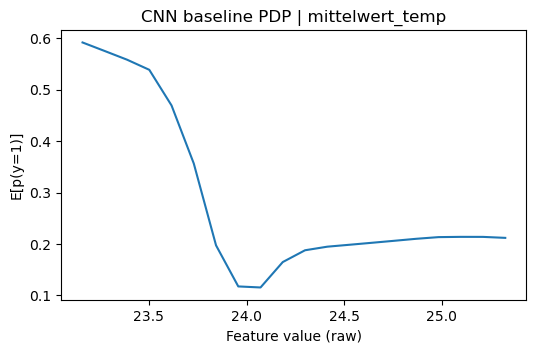


### LIME: CNN baseline LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.0347


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.8812819' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.52it/s]



### DiCE Keras: CNN baseline DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN baseline LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.0251


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.4932188' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.55it/s]



### DiCE Keras: CNN baseline DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN baseline LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.0268


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.1235263' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.52it/s]



### DiCE Keras: CNN baseline DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF baseline PDP | base=(500, 1)


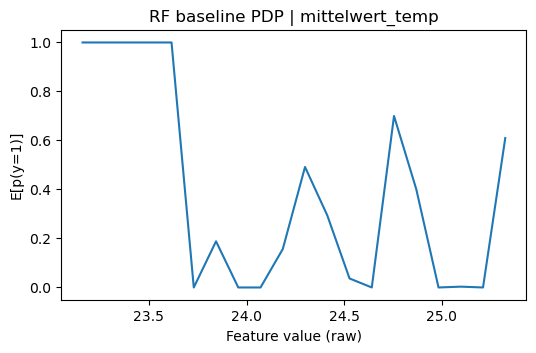


### LIME: RF baseline LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.2109


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.8836033' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF baseline DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF baseline LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.1812


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.5767525' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF baseline DiCE | point_id=57436 | found=True | idx=1996 | point_id=57436

### LIME: RF baseline LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.2173


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.7616588' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF baseline DiCE | point_id=56168 | found=True | idx=728 | point_id=56168


C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result


### PDP: CNN covariance_shift PDP | base=(500, 1)


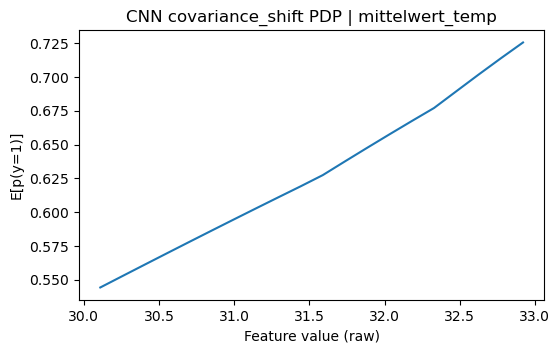


### LIME: CNN covariance_shift LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 31.84                   +0.2752


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.112905' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  5.06it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  5.03it/s]



### DiCE Keras: CNN covariance_shift DiCE | point_id=55838 | found=False | chosen_idx=398 | idx_fixed=True
Last DiCE error: UserConfigValidationException('No counterfactuals found for any of the query points! Kindly check your configuration.')

### LIME: CNN covariance_shift LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 31.84                   +0.2716


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  5.13it/s]



### DiCE Keras: CNN covariance_shift DiCE | point_id=57436 | found=False | chosen_idx=1996 | idx_fixed=True
Last DiCE error: UserConfigValidationException('No counterfactuals found for any of the query points! Kindly check your configuration.')

### LIME: CNN covariance_shift LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 31.84                   +0.2768


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.6274334' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  2.65it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec

### DiCE Keras: CNN covariance_shift DiCE | point_id=56168 | found=False | chosen_idx=728 | idx_fixed=True
Last DiCE error: UserConfigValidationException('No counterfactuals found for any of the query points! Kindly check your configuration.')

### PDP: RF covariance_shift PDP | base=(500, 1)


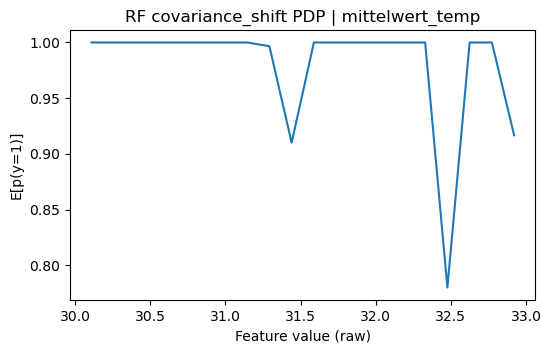


### LIME: RF covariance_shift LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 31.84                   -0.0508


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.6985954' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF covariance_shift DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF covariance_shift LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 31.84                   -0.0497


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.1658695' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but R


### PDP: CNN forgetting_A(onA) PDP | base=(500, 1)


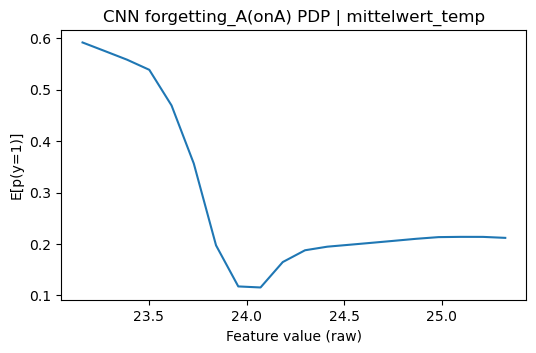


### LIME: CNN forgetting_A(onA) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.0156


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.8660955' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.47it/s]



### DiCE Keras: CNN forgetting_A(onA) DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN forgetting_A(onA) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.0216


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.026716' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.44it/s]



### DiCE Keras: CNN forgetting_A(onA) DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN forgetting_A(onA) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.0283


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5555158' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.52it/s]



### DiCE Keras: CNN forgetting_A(onA) DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF forgetting_A(onA) PDP | base=(500, 1)


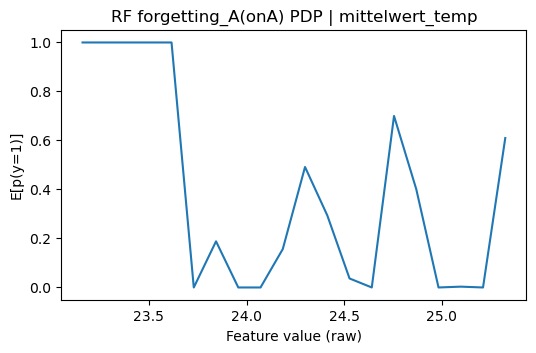


### LIME: RF forgetting_A(onA) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.2302


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.6111975' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF forgetting_A(onA) DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF forgetting_A(onA) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.2245


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.7847274' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF forgetting_A(onA) DiCE | point_id=57436 | found=True | idx=1996 | point_id=57436

### LIME: RF forgetting_A(onA) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.2118


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.3572771' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF forgetting_A(onA) DiCE | point_id=56168 | found=True | idx=728 | point_id=56168

### PDP: CNN forgetting_B(onA) PDP | base=(500, 1)


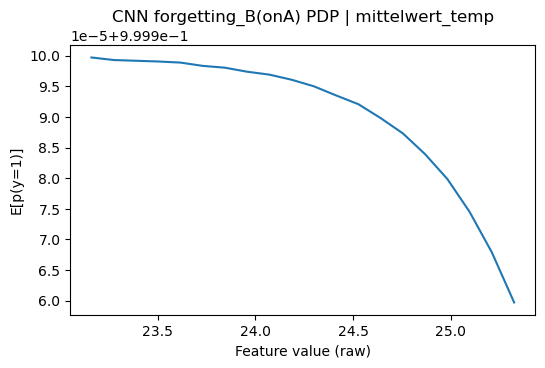


### LIME: CNN forgetting_B(onA) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.1267


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.6725912' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.51it/s]



### DiCE Keras: CNN forgetting_B(onA) DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN forgetting_B(onA) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.1166


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.5686857' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.47it/s]



### DiCE Keras: CNN forgetting_B(onA) DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN forgetting_B(onA) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.1226


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1334831' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.43it/s]



### DiCE Keras: CNN forgetting_B(onA) DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF forgetting_B(onA) PDP | base=(500, 1)


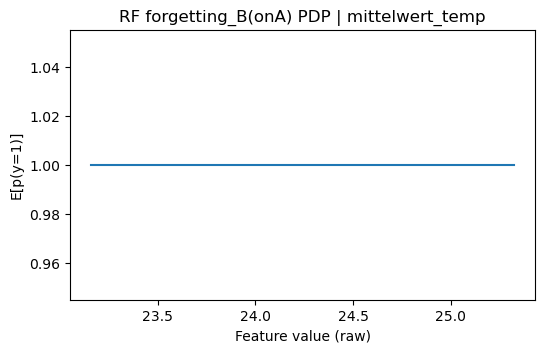


### LIME: RF forgetting_B(onA) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.0693


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.17319' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Rand


### DiCE RF: RF forgetting_B(onA) DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF forgetting_B(onA) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.0809


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.581741' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ran


### DiCE RF: RF forgetting_B(onA) DiCE | point_id=57436 | found=True | idx=1996 | point_id=57436

### LIME: RF forgetting_B(onA) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.0760


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.990959' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ran


### DiCE RF: RF forgetting_B(onA) DiCE | point_id=56168 | found=True | idx=728 | point_id=56168

### PDP: CNN forgetting_B(onB) PDP | base=(500, 1)


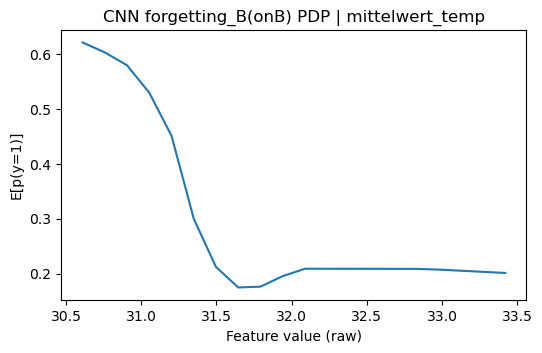


### LIME: CNN forgetting_B(onB) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 32.34                   -0.0220


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '19.0142022' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.53it/s]



### DiCE Keras: CNN forgetting_B(onB) DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN forgetting_B(onB) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 32.34                   -0.0236


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.9220604' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.50it/s]



### DiCE Keras: CNN forgetting_B(onB) DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN forgetting_B(onB) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 32.34                   -0.0261


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.0224762' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.53it/s]



### DiCE Keras: CNN forgetting_B(onB) DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF forgetting_B(onB) PDP | base=(500, 1)


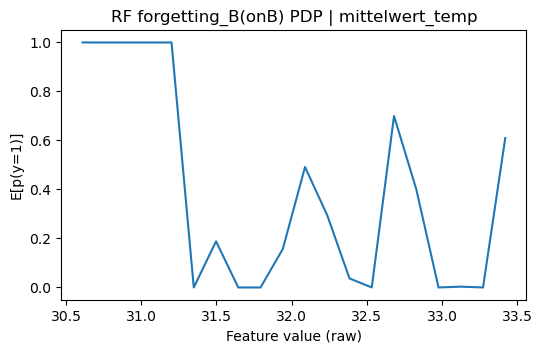


### LIME: RF forgetting_B(onB) LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 32.34                   -0.2329


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.181655106' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but


### DiCE RF: RF forgetting_B(onB) DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF forgetting_B(onB) LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 32.34                   -0.2521


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5.537912962' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but 


### DiCE RF: RF forgetting_B(onB) DiCE | point_id=57436 | found=True | idx=1996 | point_id=57436

### LIME: RF forgetting_B(onB) LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 32.34                   -0.2320


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.417358371' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but 


### DiCE RF: RF forgetting_B(onB) DiCE | point_id=56168 | found=True | idx=728 | point_id=56168


C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result


### PDP: CNN underfitting PDP | base=(500, 1)


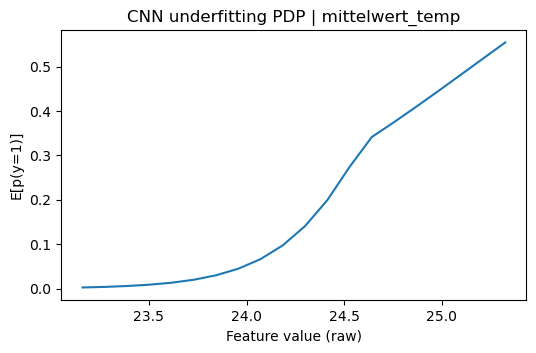


### LIME: CNN underfitting LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   +0.7785


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.782093301' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.28it/s]



### DiCE Keras: CNN underfitting DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN underfitting LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   +0.7892


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.310540945' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.30it/s]



### DiCE Keras: CNN underfitting DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN underfitting LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   +0.7740


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.966654241' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.18it/s]



### DiCE Keras: CNN underfitting DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF underfitting PDP | base=(500, 1)


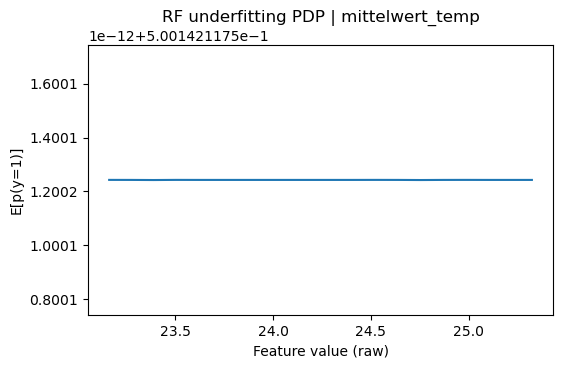


### LIME: RF underfitting LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   +0.0000


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.492400607' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
100%|██████████| 1/1 [00:00<00:00,  6.49it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec



### LIME: RF underfitting LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   +0.0000


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15.696416599' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
100%|██████████| 1/1 [00:00<00:00,  6.54it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec



### LIME: RF underfitting LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   +0.0000


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.151291404' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
100%|██████████| 1/1 [00:00<00:00,  6.67it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec

### PDP: CNN overfitting PDP | base=(500, 1)


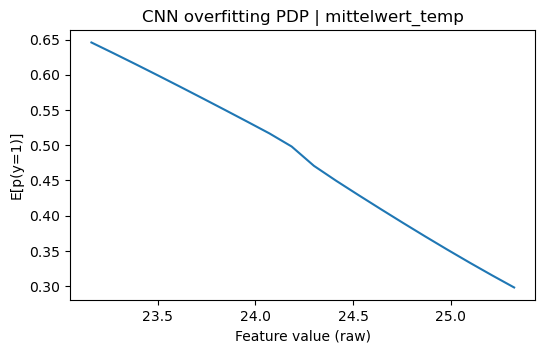


### LIME: CNN overfitting LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.4271


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.2263224' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.46it/s]



### DiCE Keras: CNN overfitting DiCE | point_id=55838 | found=True | chosen_idx=398 | idx_fixed=True

### LIME: CNN overfitting LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.4380


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '26.4748239' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.40it/s]



### DiCE Keras: CNN overfitting DiCE | point_id=57436 | found=True | chosen_idx=1996 | idx_fixed=True

### LIME: CNN overfitting LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.4239


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '42.4614592' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
100%|██████████| 1/1 [00:00<00:00,  1.29it/s]



### DiCE Keras: CNN overfitting DiCE | point_id=56168 | found=True | chosen_idx=728 | idx_fixed=True

### PDP: RF overfitting PDP | base=(500, 1)


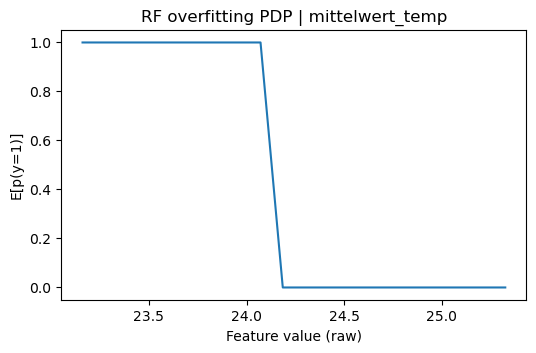


### LIME: RF overfitting LIME | point_id=55838 | idx=398 | point_id=55838 | true=0
mittelwert_temp > 24.50                   -0.7111


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '114.2717856' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but 


### DiCE RF: RF overfitting DiCE | point_id=55838 | found=True | idx=398 | point_id=55838

### LIME: RF overfitting LIME | point_id=57436 | idx=1996 | point_id=57436 | true=1
mittelwert_temp > 24.50                   -0.7203


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.7439673' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ra


### DiCE RF: RF overfitting DiCE | point_id=57436 | found=True | idx=1996 | point_id=57436

### LIME: RF overfitting LIME | point_id=56168 | idx=728 | point_id=56168 | true=0
mittelwert_temp > 24.50                   -0.7098


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\dice_ml\explainer_interfaces\dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '107.2000336' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\ko\Anaconda3\envs\TF-Explain\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but 


### DiCE RF: RF overfitting DiCE | point_id=56168 | found=True | idx=728 | point_id=56168
DONE. Scenarios: ['baseline', 'covariance_shift', 'environmental_shift', 'model_drift', 'catastrophic_forgetting', 'underfitting', 'overfitting']


In [12]:
# ============================================================
# 8) MAIN (aktivieren sobald df_base/feature_cols gesetzt sind)
# ============================================================
df = prepare_df(df_base)
# Stable IDs for comparing the same logical point across scenarios
ID_COL = CONFIG.get("id_col", "point_id")
df = ensure_point_id(df, ID_COL)

# Domain A: zeitbasiert splitten
df_train_A, df_test_A = split_time_ordered(df, CONFIG["train_frac"])
df_tr_A, df_val_A = make_train_val(df_train_A, CONFIG["val_frac_within_train"])

# Baseline-Scaler nur aus Train (Domain A)
scaler_A = make_scaler_from_train(df_tr_A, feature_cols)

# Train clean models (Domain A)
cnn_clean = train_cnn_on_df(df_tr_A, scaler_A, feature_cols, label_col, epochs=200, seed=CONFIG["seed"])
rf_clean  = train_rf_pipeline(df_tr_A, feature_cols, label_col)

# Szenarien (CMAPSS-ähnlich)
scenarios = make_scenarios_like_cmapss(df_train_A=df_tr_A, df_test_A=df_test_A, feature_cols=feature_cols)
ALL_RESULTS = {}

# ------------------------------------------------------------
# 8.1 baseline / cov / env: evaluate-only shifts (no retraining)
# ------------------------------------------------------------
for name in ["baseline", "covariance_shift", "environmental_shift"]:
    sc = scenarios[name]
    met_cnn = eval_cnn_on_df(cnn_clean, sc["test"], scaler_A, feature_cols, label_col)
    met_rf  = eval_rf_on_df(rf_clean, sc["test"], feature_cols, label_col)
    xai = run_xai_bundle_for_df(name, sc["test"], feature_cols, label_col, scaler_A, cnn_clean, rf_clean)
    ALL_RESULTS[name] = {"metrics": {"cnn": met_cnn, "rf": met_rf}, "xai": xai, "meta": sc.get("meta", {})}

# ------------------------------------------------------------
# 8.2 model drift: MODEL-only (Train drifted, Test bleibt clean)
# ------------------------------------------------------------
sc = scenarios["model_drift"]

cnn_drift = tf.keras.models.clone_model(cnn_clean)
cnn_drift.set_weights(cnn_clean.get_weights())
cnn_drift.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[metrics.AUC(name="auc"), metrics.Precision(name="prec"), metrics.Recall(name="rec")]
)
cnn_drift = continue_train_cnn(
    cnn_drift, sc["train"], scaler_A, feature_cols, label_col,
    extra_epochs=CONFIG["drift_extra_epochs"], batch_size=32
)

rf_drift = train_rf_pipeline(sc["train"], feature_cols, label_col) if CONFIG["rf_retrain_on_drift"] else rf_clean

met_cnn = eval_cnn_on_df(cnn_drift, sc["test"], scaler_A, feature_cols, label_col)
met_rf  = eval_rf_on_df(rf_drift, sc["test"], feature_cols, label_col)
xai = run_xai_bundle_for_df("model_drift", sc["test"], feature_cols, label_col, scaler_A, cnn_drift, rf_drift)
ALL_RESULTS["model_drift"] = {"metrics": {"cnn": met_cnn, "rf": met_rf}, "xai": xai, "meta": sc.get("meta", {})}

# ------------------------------------------------------------
# 8.3 catastrophic forgetting: A -> train on B -> eval on A and B
# ------------------------------------------------------------
sc = scenarios["catastrophic_forgetting"]
cnn_A = cnn_clean
rf_A  = rf_clean

cnn_B = tf.keras.models.clone_model(cnn_clean)
cnn_B.set_weights(cnn_clean.get_weights())
cnn_B.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[metrics.AUC(name="auc"), metrics.Precision(name="prec"), metrics.Recall(name="rec")]
)
cnn_B = continue_train_cnn(
    cnn_B, sc["train_B"], scaler_A, feature_cols, label_col,
    extra_epochs=CONFIG["forget_ft_epochs"], batch_size=32
)
rf_B = train_rf_pipeline(sc["train_B"], feature_cols, label_col) if CONFIG["forget_rf_retrain"] else rf_A

met_AA = {"cnn": eval_cnn_on_df(cnn_A, sc["test_A"], scaler_A, feature_cols, label_col),
          "rf":  eval_rf_on_df(rf_A, sc["test_A"], feature_cols, label_col)}
met_BA = {"cnn": eval_cnn_on_df(cnn_B, sc["test_A"], scaler_A, feature_cols, label_col),
          "rf":  eval_rf_on_df(rf_B, sc["test_A"], feature_cols, label_col)}
met_BB = {"cnn": eval_cnn_on_df(cnn_B, sc["test_B"], scaler_A, feature_cols, label_col),
          "rf":  eval_rf_on_df(rf_B, sc["test_B"], feature_cols, label_col)}

xai_AA = run_xai_bundle_for_df("forgetting_A(onA)", sc["test_A"], feature_cols, label_col, scaler_A, cnn_A, rf_A)
xai_BA = run_xai_bundle_for_df("forgetting_B(onA)", sc["test_A"], feature_cols, label_col, scaler_A, cnn_B, rf_B)
xai_BB = run_xai_bundle_for_df("forgetting_B(onB)", sc["test_B"], feature_cols, label_col, scaler_A, cnn_B, rf_B)

ALL_RESULTS["catastrophic_forgetting"] = {
    "metrics": {"A_on_A": met_AA, "B_on_A": met_BA, "B_on_B": met_BB},
    "xai": {"A_on_A": xai_AA, "B_on_A": xai_BA, "B_on_B": xai_BB},
    "meta": sc.get("meta", {})
}

# ------------------------------------------------------------
# 8.4 underfitting / overfitting: eigenes Training pro Szenario
# ------------------------------------------------------------
for name in ["underfitting", "overfitting"]:
    sc = scenarios[name]

    # eigener Scaler pro Under/Over-Trainset
    scaler_local = make_scaler_from_train(sc["train"], feature_cols)

    cnn_local = train_cnn_on_df(
        sc["train"], scaler_local, feature_cols, label_col,
        epochs=CONFIG.get("underover_epochs", 120),
        seed=CONFIG["seed"]
    )
    rf_local  = train_rf_pipeline(sc["train"], feature_cols, label_col)

    met_cnn = eval_cnn_on_df(cnn_local, sc["test"], scaler_local, feature_cols, label_col)
    met_rf  = eval_rf_on_df(rf_local, sc["test"], feature_cols, label_col)
    xai = run_xai_bundle_for_df(name, sc["test"], feature_cols, label_col, scaler_local, cnn_local, rf_local)

    ALL_RESULTS[name] = {"metrics": {"cnn": met_cnn, "rf": met_rf}, "xai": xai, "meta": sc.get("meta", {})}

print("DONE. Scenarios:", list(ALL_RESULTS.keys()))


In [13]:
# ============================================================
# 9) Übersicht: XAI pro Szenario & Modell
# ============================================================
def print_xai_overview(ALL_RESULTS: Dict[str, Any]):
    print("="*90)
    print("XAI OVERVIEW pro Szenario / Modell")
    print("="*90)

    def one_bundle(name, bundle):
        print("\n" + "-"*90)
        print("SCENARIO:", name)
        cnn = bundle.get("cnn", {})
        rf  = bundle.get("rf",  {})
        if cnn:
            print("[CNN] gradients_top, PDP, LIME, DiCE, Rules")
            print("  gradients_top:", len(cnn.get("gradients_top", [])))
            print("  LIME status:", (cnn.get("lime", {}) or {}).get("status", "n/a"))
            print("  DiCE status:", (cnn.get("dice", {}) or {}).get("status", "n/a"))
            print("  Rules:", len(cnn.get("rules_top", [])))
        if rf:
            print("[RF ] PDP, LIME, DiCE, Rules")
            print("  LIME status:", (rf.get("lime", {}) or {}).get("status", "n/a"))
            print("  DiCE status:", (rf.get("dice", {}) or {}).get("status", "n/a"))
            print("  Rules:", len(rf.get("rules_top", [])))

    for scen, payload in ALL_RESULTS.items():
        if scen != "catastrophic_forgetting":
            one_bundle(scen, payload["xai"])
        else:
            for subk in ["A_on_A", "B_on_A", "B_on_B"]:
                one_bundle(f"{scen}::{subk}", payload["xai"][subk])

print_xai_overview(ALL_RESULTS)


XAI OVERVIEW pro Szenario / Modell

------------------------------------------------------------------------------------------
SCENARIO: baseline
[CNN] gradients_top, PDP, LIME, DiCE, Rules
  gradients_top: 1
  LIME status: ok
  DiCE status: ok
  Rules: 0
[RF ] PDP, LIME, DiCE, Rules
  LIME status: ok
  DiCE status: ok
  Rules: 0

------------------------------------------------------------------------------------------
SCENARIO: covariance_shift
[CNN] gradients_top, PDP, LIME, DiCE, Rules
  gradients_top: 1
  LIME status: ok
  DiCE status: no_cf
  Rules: 0
[RF ] PDP, LIME, DiCE, Rules
  LIME status: ok
  DiCE status: ok
  Rules: 0

------------------------------------------------------------------------------------------
SCENARIO: environmental_shift
[CNN] gradients_top, PDP, LIME, DiCE, Rules
  gradients_top: 1
  LIME status: ok
  DiCE status: ok
  Rules: 0
[RF ] PDP, LIME, DiCE, Rules
  LIME status: ok
  DiCE status: ok
  Rules: 0

---------------------------------------------------

In [14]:
# ============================================================
# 9) ÜBERSICHT (inkl. Underfitting/Overfitting)
# ============================================================

EXPECTED_SCENARIOS = [
    "baseline",
    "covariance_shift",
    "environmental_shift",
    "model_drift",
    "catastrophic_forgetting",
    "underfitting",
    "overfitting",
]

def build_metrics_df(all_results: dict) -> pd.DataFrame:
    rows = []
    for scen, payload in all_results.items():
        met = payload.get("metrics", {})

        # catastrophic forgetting hat Sub-Sets (A_on_A, B_on_A, B_on_B)
        if scen == "catastrophic_forgetting":
            for sub, sub_met in met.items():
                for model_key in ["cnn", "rf"]:
                    d = sub_met.get(model_key, {})
                    row = {"scenario": scen, "subset": sub, "model": model_key}
                    row.update({k: v for k, v in d.items() if k != "cm"})
                    rows.append(row)
        else:
            for model_key in ["cnn", "rf"]:
                d = met.get(model_key, {})
                row = {"scenario": scen, "subset": "-", "model": model_key}
                row.update({k: v for k, v in d.items() if k != "cm"})
                rows.append(row)

    df = pd.DataFrame(rows)

    # Platzhalter, damit Szenarien auch sichtbar sind, wenn ein Run abbricht
    present = set(df["scenario"].tolist()) if "scenario" in df.columns else set()
    for s in EXPECTED_SCENARIOS:
        if s not in present:
            for model_key in ["cnn", "rf"]:
                df = pd.concat([df, pd.DataFrame([{"scenario": s, "subset": "-", "model": model_key}])], ignore_index=True)

    scen_order = {s: i for i, s in enumerate(EXPECTED_SCENARIOS)}
    df["scenario_order"] = df["scenario"].map(lambda s: scen_order.get(s, 999))
    df = df.sort_values(["scenario_order", "scenario", "subset", "model"]).drop(columns=["scenario_order"]).reset_index(drop=True)
    return df

metrics_df = build_metrics_df(ALL_RESULTS)
pd.options.display.float_format = "{:.6f}".format
metrics_df


,scenario,subset,model,roc_auc,confusion,report
0,baseline,-,cnn,0.846924,"[[11128, 54], [4352, 8226]]","{'0': {'precision': 0.7188630490956073, 'recal..."
1,baseline,-,rf,0.865976,"[[9544, 1638], [2908, 9670]]","{'0': {'precision': 0.7664632187600385, 'recal..."
2,covariance_shift,-,cnn,0.162958,"[[0, 11182], [0, 12578]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
3,covariance_shift,-,rf,0.518649,"[[410, 10772], [478, 12100]]","{'0': {'precision': 0.4617117117117117, 'recal..."
4,environmental_shift,-,cnn,0.603223,"[[11121, 61], [11603, 975]]","{'0': {'precision': 0.48939447280408377, 'reca..."
5,environmental_shift,-,rf,0.519579,"[[8804, 2378], [9533, 3045]]","{'0': {'precision': 0.4801221573867045, 'recal..."
6,model_drift,-,cnn,0.836982,"[[2, 11180], [158, 12420]]","{'0': {'precision': 0.0125, 'recall': 0.000178..."
7,model_drift,-,rf,0.492935,"[[3, 11179], [115, 12463]]","{'0': {'precision': 0.025423728813559324, 'rec..."
8,catastrophic_forgetting,A_on_A,cnn,0.846924,"[[11128, 54], [4352, 8226]]","{'0': {'precision': 0.7188630490956073, 'recal..."
9,catastrophic_forgetting,A_on_A,rf,0.865976,"[[9544, 1638], [2908, 9670]]","{'0': {'precision': 0.7664632187600385, 'recal..."


In [15]:
# ============================================================
# 9) ÜBERSICHT (inkl. Underfitting/Overfitting)
# ============================================================

EXPECTED_SCENARIOS = [
    "baseline",
    "covariance_shift",
    "environmental_shift",
    "model_drift",
    "catastrophic_forgetting",
    "underfitting",
    "overfitting",
]

def build_metrics_df(all_results: dict) -> pd.DataFrame:
    rows = []
    for scen, payload in all_results.items():
        met = payload.get("metrics", {})

        # catastrophic forgetting hat Sub-Sets (A_on_A, B_on_A, B_on_B)
        if scen == "catastrophic_forgetting":
            for sub, sub_met in met.items():
                for model_key in ["cnn", "rf"]:
                    d = sub_met.get(model_key, {})
                    row = {"scenario": scen, "subset": sub, "model": model_key}
                    row.update({k: v for k, v in d.items() if k != "cm"})
                    rows.append(row)
        else:
            for model_key in ["cnn", "rf"]:
                d = met.get(model_key, {})
                row = {"scenario": scen, "subset": "-", "model": model_key}
                row.update({k: v for k, v in d.items() if k != "cm"})
                rows.append(row)

    df = pd.DataFrame(rows)

    # Platzhalter, damit Szenarien auch sichtbar sind, wenn ein Run abbricht
    present = set(df["scenario"].tolist()) if "scenario" in df.columns else set()
    for s in EXPECTED_SCENARIOS:
        if s not in present:
            for model_key in ["cnn", "rf"]:
                df = pd.concat([df, pd.DataFrame([{"scenario": s, "subset": "-", "model": model_key}])], ignore_index=True)

    scen_order = {s: i for i, s in enumerate(EXPECTED_SCENARIOS)}
    df["scenario_order"] = df["scenario"].map(lambda s: scen_order.get(s, 999))
    df = df.sort_values(["scenario_order", "scenario", "subset", "model"]).drop(columns=["scenario_order"]).reset_index(drop=True)
    return df

metrics_df = build_metrics_df(ALL_RESULTS)
pd.options.display.float_format = "{:.6f}".format
metrics_df


,scenario,subset,model,roc_auc,confusion,report
0,baseline,-,cnn,0.846924,"[[11128, 54], [4352, 8226]]","{'0': {'precision': 0.7188630490956073, 'recal..."
1,baseline,-,rf,0.865976,"[[9544, 1638], [2908, 9670]]","{'0': {'precision': 0.7664632187600385, 'recal..."
2,covariance_shift,-,cnn,0.162958,"[[0, 11182], [0, 12578]]","{'0': {'precision': 0.0, 'recall': 0.0, 'f1-sc..."
3,covariance_shift,-,rf,0.518649,"[[410, 10772], [478, 12100]]","{'0': {'precision': 0.4617117117117117, 'recal..."
4,environmental_shift,-,cnn,0.603223,"[[11121, 61], [11603, 975]]","{'0': {'precision': 0.48939447280408377, 'reca..."
5,environmental_shift,-,rf,0.519579,"[[8804, 2378], [9533, 3045]]","{'0': {'precision': 0.4801221573867045, 'recal..."
6,model_drift,-,cnn,0.836982,"[[2, 11180], [158, 12420]]","{'0': {'precision': 0.0125, 'recall': 0.000178..."
7,model_drift,-,rf,0.492935,"[[3, 11179], [115, 12463]]","{'0': {'precision': 0.025423728813559324, 'rec..."
8,catastrophic_forgetting,A_on_A,cnn,0.846924,"[[11128, 54], [4352, 8226]]","{'0': {'precision': 0.7188630490956073, 'recal..."
9,catastrophic_forgetting,A_on_A,rf,0.865976,"[[9544, 1638], [2908, 9670]]","{'0': {'precision': 0.7664632187600385, 'recal..."


In [16]:
import os, json
from pprint import pformat

def _safe_str(obj, max_chars=12000):
    try:
        s = pformat(obj, width=120)
    except Exception:
        try:
            s = str(obj)
        except Exception:
            s = repr(obj)
    if len(s) > max_chars:
        s = s[:max_chars] + "\n... [TRUNCATED] ..."
    return s

def export_xai_results_to_txt(all_results: dict, out_path: str = "XAI_RESULTS.txt"):
    """
    Schreibt eine lesbare TXT:
    SCENARIO -> MODEL -> METHOD -> point_id (falls vorhanden)
    """
    lines = []
    for scen, payload in all_results.items():
        lines.append("=" * 90)
        lines.append(f"SCENARIO: {scen}")
        lines.append("=" * 90)

        xai = payload.get("xai", None)
        if xai is None:
            lines.append("[WARN] No xai found.\n")
            continue

        # In unseren Notebooks ist xai typischerweise dict mit keys wie "cnn","rf" oder "dense_nn","svm"
        if isinstance(xai, dict) and any(k in xai for k in ["cnn", "rf", "dense_nn", "svm"]):
            model_blocks = xai.items()
        else:
            model_blocks = [("xai", xai)]

        for model_name, model_xai in model_blocks:
            lines.append(f"\n--- MODEL: {model_name} ---")

            if not isinstance(model_xai, dict):
                lines.append(_safe_str(model_xai))
                continue

            # Methoden sortiert ausgeben
            for method_name in sorted(model_xai.keys()):
                lines.append(f"\n[METHOD] {method_name}")
                val = model_xai[method_name]

                # Falls es ein Dict nach point_id ist: hübsch ausgeben
                if isinstance(val, dict) and all(isinstance(k, int) for k in val.keys()):
                    for pid in sorted(val.keys()):
                        lines.append(f"\n  point_id={pid}")
                        lines.append(_safe_str(val[pid]))
                else:
                    lines.append(_safe_str(val))

        # Meta optional
        meta = payload.get("meta", None)
        if meta is not None:
            lines.append("\n--- META ---")
            lines.append(_safe_str(meta))

        lines.append("\n")

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    print(f"Wrote: {os.path.abspath(out_path)}")

# Beispiel:
export_xai_results_to_txt(ALL_RESULTS, "XAI_RESULTS.txt")


Wrote: C:\Users\ko\XAI_RESULTS.txt


In [17]:
for scen, payload in ALL_RESULTS.items():
    xai = payload["xai"]
    print("\n====", scen, "====")
    print("Local points:", xai.get("local_points", []))

    # Beispiel CNN
    if "cnn" in xai:
        cnn = xai["cnn"]
        if "lime_local" in cnn:
            print("CNN LIME point_ids:", list(cnn["lime_local"].keys()))
        if "dice_local" in cnn:
            print("CNN DiCE point_ids:", list(cnn["dice_local"].keys()))

    # Beispiel RF
    if "rf" in xai:
        rf = xai["rf"]
        if "lime_local" in rf:
            print("RF LIME point_ids:", list(rf["lime_local"].keys()))
        if "dice_local" in rf:
            print("RF DiCE point_ids:", list(rf["dice_local"].keys()))



==== baseline ====
Local points: [{'point_id': 55838, 'iloc': 398, 'y_true': 0, 'status': 'ok'}, {'point_id': 57436, 'iloc': 1996, 'y_true': 1, 'status': 'ok'}, {'point_id': 56168, 'iloc': 728, 'y_true': 0, 'status': 'ok'}]
CNN LIME point_ids: [55838, 57436, 56168]
CNN DiCE point_ids: [55838, 57436, 56168]
RF LIME point_ids: [55838, 57436, 56168]
RF DiCE point_ids: [55838, 57436, 56168]

==== covariance_shift ====
Local points: [{'point_id': 55838, 'iloc': 398, 'y_true': 0, 'status': 'ok'}, {'point_id': 57436, 'iloc': 1996, 'y_true': 1, 'status': 'ok'}, {'point_id': 56168, 'iloc': 728, 'y_true': 0, 'status': 'ok'}]
CNN LIME point_ids: [55838, 57436, 56168]
CNN DiCE point_ids: [55838, 57436, 56168]
RF LIME point_ids: [55838, 57436, 56168]
RF DiCE point_ids: [55838, 57436, 56168]

==== environmental_shift ====
Local points: [{'point_id': 55838, 'iloc': 398, 'y_true': 0, 'status': 'ok'}, {'point_id': 57436, 'iloc': 1996, 'y_true': 1, 'status': 'ok'}, {'point_id': 56168, 'iloc': 728, 'y_t